WEEK 4 — ANALYSIS OF 100-IMAGE ORIENTATION ESTIMATION RESULTS

The Week-3 results for the same 100 vehicle images are analysed for:

1. Overall method performance
2. Error distribution
3. Ground-truth versus estimated orientation
4. Class-wise performance

Methods compared:
• PCA
• Hough Transform
• Contour-based method

In [1]:
# =========================================================
# WEEK 4 - CELL 2
# LOAD WEEK-3 RESULTS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from google.colab import drive
from IPython.display import display


# ---------------------------------------------------------
# Mount Google Drive
# ---------------------------------------------------------

drive.mount("/content/drive")


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

DATA_DIR = Path(
    "/content/drive/MyDrive/ECE501_DRASHTI"
)

WEEK3_DIR = (
    DATA_DIR / "Week3_Results"
)

ERROR_TABLE_PATH = (
    WEEK3_DIR /
    "week3_100_image_error_table.csv"
)


# ---------------------------------------------------------
# Check file
# ---------------------------------------------------------

if not ERROR_TABLE_PATH.exists():

    raise FileNotFoundError(
        f"Week-3 error table not found:\n"
        f"{ERROR_TABLE_PATH}"
    )


# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

df = pd.read_csv(
    ERROR_TABLE_PATH
)


print(
    "Week-3 results loaded successfully."
)

print(
    "Number of vehicles:",
    len(df)
)

print(
    "\nColumns:"
)

for col in df.columns:
    print(
        " -",
        col
    )


display(
    df.head()
)

Mounted at /content/drive
Week-3 results loaded successfully.
Number of vehicles: 100

Columns:
 - Vehicle_ID
 - Image_ID
 - Vehicle_Number
 - Class_ID
 - Vehicle_Class
 - Difficulty
 - Ground_Truth_Heading_deg
 - Ground_Truth_Orientation_deg
 - PCA_Estimated_Orientation_deg
 - PCA_Angular_Error_deg
 - Hough_Estimated_Orientation_deg
 - Hough_Angular_Error_deg
 - Contour_Estimated_Orientation_deg
 - Contour_Angular_Error_deg


,Vehicle_ID,Image_ID,Vehicle_Number,Class_ID,Vehicle_Class,Difficulty,Ground_Truth_Heading_deg,Ground_Truth_Orientation_deg,PCA_Estimated_Orientation_deg,PCA_Angular_Error_deg,Hough_Estimated_Orientation_deg,Hough_Angular_Error_deg,Contour_Estimated_Orientation_deg,Contour_Angular_Error_deg
0,KNyT_zacV_LpYg_vehicle_1,KNyT_zacV_LpYg,1,5,MotorCycle,0,283.20,76.80,72.51,4.29,82.44,5.64,86.31,9.51
1,IwEd_XCYw_iwrB_vehicle_1,IwEd_XCYw_iwrB,1,0,Auto3WCargo,0,214.74,34.74,5.61,29.13,54.72,19.98,0.00,34.74
2,C2g2_vYbb_ihYH_vehicle_1,C2g2_vYbb_ihYH,1,7,SUV,0,239.58,59.58,50.14,9.44,69.57,9.99,52.43,7.15
3,gqbe_NCQI_MTLw_vehicle_1,gqbe_NCQI_MTLw,1,7,SUV,0,171.34,8.66,0.84,7.82,10.04,1.38,0.00,8.66
4,boDi_WlMN_s88Y_vehicle_1,boDi_WlMN_s88Y,1,9,Tanker,0,97.00,83.00,83.19,0.19,86.27,3.27,90.00,7.00


CREATE WEEK-4 OUTPUT FOLDERS

Graphs:
1. Mean angular error
2. Error boxplot
3. Ground-truth versus estimated orientation
4. Class-wise mean angular error

Tables:
1. Overall method comparison
2. Class-wise comparison

In [2]:
# =========================================================
# WEEK 4 - CELL 4
# CREATE OUTPUT FOLDERS
# =========================================================

WEEK4_DIR = (
    DATA_DIR / "Week4_Results"
)

GRAPHS_DIR = (
    WEEK4_DIR / "graphs"
)

TABLES_DIR = (
    WEEK4_DIR / "tables"
)


for folder in [
    WEEK4_DIR,
    GRAPHS_DIR,
    TABLES_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "Week-4 output folders ready."
)

Week-4 output folders ready.


TABLE 1 — OVERALL METHOD COMPARISON

The overall performance of PCA, Hough Transform and Contour-based orientation estimation is compared using:

• Successful predictions
• Failed predictions
• Success rate
• Mean angular error
• Median angular error
• Standard deviation
• Maximum angular error

In [3]:
# =========================================================
# WEEK 4 - CELL 6
# CREATE OVERALL METHOD COMPARISON TABLE
# =========================================================

methods = {

    "PCA": {
        "prediction":
            "PCA_Estimated_Orientation_deg",
        "error":
            "PCA_Angular_Error_deg"
    },

    "Hough": {
        "prediction":
            "Hough_Estimated_Orientation_deg",
        "error":
            "Hough_Angular_Error_deg"
    },

    "Contour": {
        "prediction":
            "Contour_Estimated_Orientation_deg",
        "error":
            "Contour_Angular_Error_deg"
    }
}


overall_rows = []


for method, cols in methods.items():

    predictions = df[
        cols["prediction"]
    ]

    errors = df[
        cols["error"]
    ].dropna()


    total = len(df)

    successful = (
        predictions.notna().sum()
    )

    failed = (
        total - successful
    )


    overall_rows.append({

        "Method":
            method,

        "Total_Images":
            total,

        "Successful":
            successful,

        "Failed":
            failed,

        "Success_Rate_%":
            100
            * successful
            / total,

        "Mean_Angular_Error_deg":
            errors.mean(),

        "Median_Angular_Error_deg":
            errors.median(),

        "Std_Angular_Error_deg":
            errors.std(),

        "Maximum_Angular_Error_deg":
            errors.max()
    })


overall_table = pd.DataFrame(
    overall_rows
)


# Round values
numeric_columns = [
    "Success_Rate_%",
    "Mean_Angular_Error_deg",
    "Median_Angular_Error_deg",
    "Std_Angular_Error_deg",
    "Maximum_Angular_Error_deg"
]


overall_table[
    numeric_columns
] = overall_table[
    numeric_columns
].round(2)


display(
    overall_table
)


# Save
overall_table_path = (
    TABLES_DIR /
    "01_overall_method_comparison.csv"
)


overall_table.to_csv(
    overall_table_path,
    index=False
)


print(
    "\nSaved:",
    overall_table_path
)

,Method,Total_Images,Successful,Failed,Success_Rate_%,Mean_Angular_Error_deg,Median_Angular_Error_deg,Std_Angular_Error_deg,Maximum_Angular_Error_deg
0,PCA,100,100,0,100.0,10.74,4.85,16.11,81.71
1,Hough,100,98,2,98.0,12.46,4.18,20.44,82.39
2,Contour,100,100,0,100.0,10.97,5.72,16.44,89.00



Saved: /content/drive/MyDrive/ECE501_DRASHTI/Week4_Results/tables/01_overall_method_comparison.csv


GRAPH 1 — MEAN ANGULAR ERROR

This graph compares the mean angular error of PCA, Hough Transform and Contour-based orientation estimation.

Lower error indicates better agreement with the ground-truth orientation.

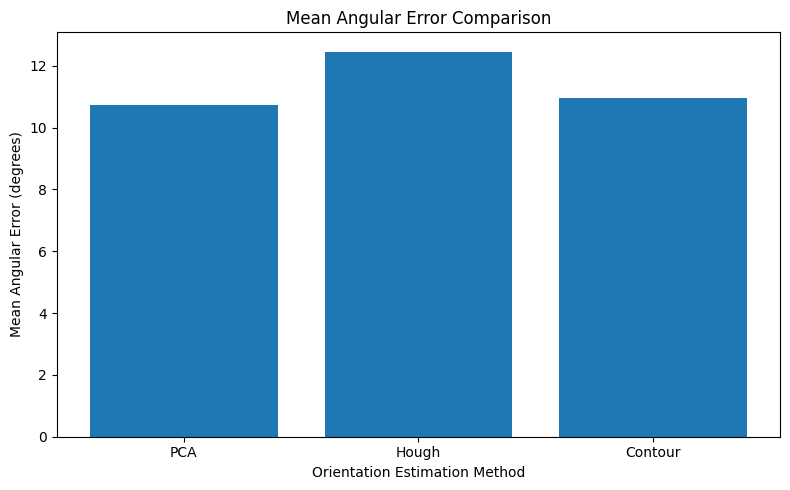

Saved: /content/drive/MyDrive/ECE501_DRASHTI/Week4_Results/graphs/01_mean_angular_error.png


In [4]:
# =========================================================
# WEEK 4 - CELL 8
# GRAPH 1: MEAN ANGULAR ERROR
# =========================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    overall_table["Method"],
    overall_table[
        "Mean_Angular_Error_deg"
    ]
)

plt.xlabel(
    "Orientation Estimation Method"
)

plt.ylabel(
    "Mean Angular Error (degrees)"
)

plt.title(
    "Mean Angular Error Comparison"
)

plt.tight_layout()


mean_error_path = (
    GRAPHS_DIR /
    "01_mean_angular_error.png"
)


plt.savefig(
    mean_error_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    mean_error_path
)